In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Read CSV
csv_filename = 'decmakdata_experi_1.csv'
df = pd.read_csv(csv_filename)

# check basic info about the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

# colnames
print("\nUnique values in key columns:")
for col in df.columns:
    if df[col].nunique() < 20: 
        print(f"{col}: {df[col].unique()}")

Dataset shape: (14788, 29)

Column names:
['phase', 'condition', 'block', 'height', 'stake', 'signal', 'reqSSD', 'outcome', 'choice', 'resp1', 'resp2', 'rt1', 'rt2', 'amount', 'balance', 'bar1', 'bar2', 'bar3', 'bar4', 'bar5', 'bar6', 'trueSSD', 'control', 'group', 'subject', 'outcome_prev', 'first', 'part', 'trial_n']

First few rows:
    phase condition  block  height   stake    signal  reqSSD outcome  choice  \
0  experi    noload      3      50     low  nosignal       0     win       5   
1  experi    noload      3      50  medium  nosignal       0    loss       1   
2  experi    noload      3      50    high  nosignal       0    loss       3   
3  experi    noload      3      40  medium  nosignal       0    loss       2   
4  experi    noload      3      50    high  nosignal       0    loss       3   

   resp1  ...  bar5  bar6  trueSSD  control  group  subject  outcome_prev  \
0      4  ...     2     4        0     0.01  bSTOP        1        neutr6   
1      4  ...     6     3  

Plotting the choices of 3 randomly picked subjects from each group. Colours indicate condition

Randomly selected subjects: [np.int64(3), np.int64(8), np.int64(27), np.int64(44), np.int64(28), np.int64(29)]


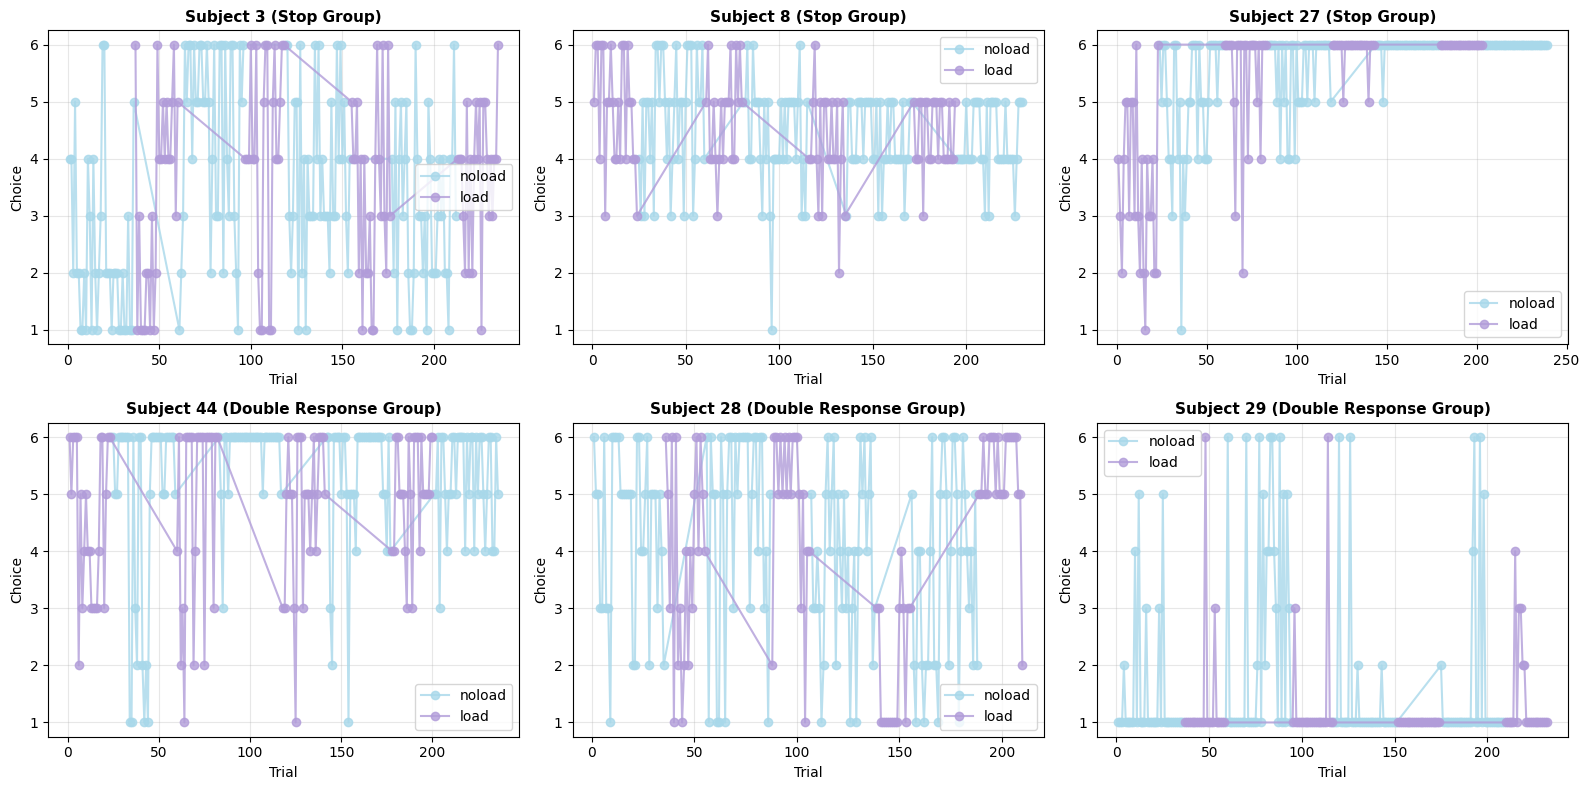

In [ ]:
# Define the function
def subject_by_condition(df, subject_id, group_col='group', trial_col='trial_n', 
                               choice_col='choice', condition_col='condition'):
    """Plot a single subject's choices with load condition indicated by colour"""
    
    subject_data = df[df['subject'] == subject_id].sort_values(trial_col)
    group = subject_data[group_col].iloc[0]
    
    fig, ax = plt.subplots(figsize=(14, 4))
    
    # Split data by condition
    load_data = subject_data[subject_data[condition_col] == 'load']
    noload_data = subject_data[subject_data[condition_col] == 'noload']
    
    # Plot with different colours
    ax.plot(load_data[trial_col], load_data[choice_col], 
            'o-', color='#B19CD9', markersize=5, linewidth=1.5, 
            alpha=0.8, label='load')
    ax.plot(noload_data[trial_col], noload_data[choice_col], 
            'o-', color='#A8D8EA', markersize=5, linewidth=1.5, 
            alpha=0.8, label='noload')
    
    ax.set_xlabel('Trial', fontsize=11)
    ax.set_ylabel('Choice', fontsize=11)
    ax.set_title(f'Subject {subject_id} - {group} group', fontsize=12, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    return fig, ax

# Setting seed for reproducibility
np.random.seed(41)  

# Randomly sampling 3 subjects from each group
subjects_per_group = 3
interesting_subjects = []

for group in df['group'].unique()[:2]:  # Assuming 2 groups
    group_subjects = df[df['group'] == group]['subject'].unique()
    random_subjects = np.random.choice(group_subjects, size=subjects_per_group, replace=False)
    interesting_subjects.extend(random_subjects)

print(f"Randomly selected subjects: {interesting_subjects}")

# Create the figure 
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for idx, subject in enumerate(interesting_subjects):
    row = idx // 3
    col = idx % 3
    
    subject_data = df[df['subject'] == subject].sort_values('trial_n')
    group = subject_data['group'].iloc[0]
    
    # Split data by condition
    load_data = subject_data[subject_data['condition'] == 'load']
    noload_data = subject_data[subject_data['condition'] == 'noload']

    axes[row, col].plot(noload_data['trial_n'], noload_data['choice'], 
                        'o-', color='#A8D8EA', markersize=6, linewidth=1.5, 
                        alpha=0.8, label='noload')
    axes[row, col].plot(load_data['trial_n'], load_data['choice'], 
                        'o-', color='#B19CD9', markersize=6, linewidth=1.5, 
                        alpha=0.8, label='load')
    
    axes[row, col].set_title(
    f"Subject {subject} "
    f"({'Stop' if group == "bSTOP" else 'Double Response'} Group)",
    fontsize=11,
    fontweight='bold')

    axes[row, col].set_xlabel('Trial', fontsize=10)
    axes[row, col].set_ylabel('Choice', fontsize=10)
    axes[row, col].legend(loc='best')
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('individual_subjects_detailed.png', dpi=300, bbox_inches='tight')
plt.savefig('individual_subjects_detailed.pdf', bbox_inches='tight')
plt.show()

Adding stakes

Randomly selected subjects: [np.int64(3), np.int64(8), np.int64(27), np.int64(44), np.int64(28), np.int64(29)]


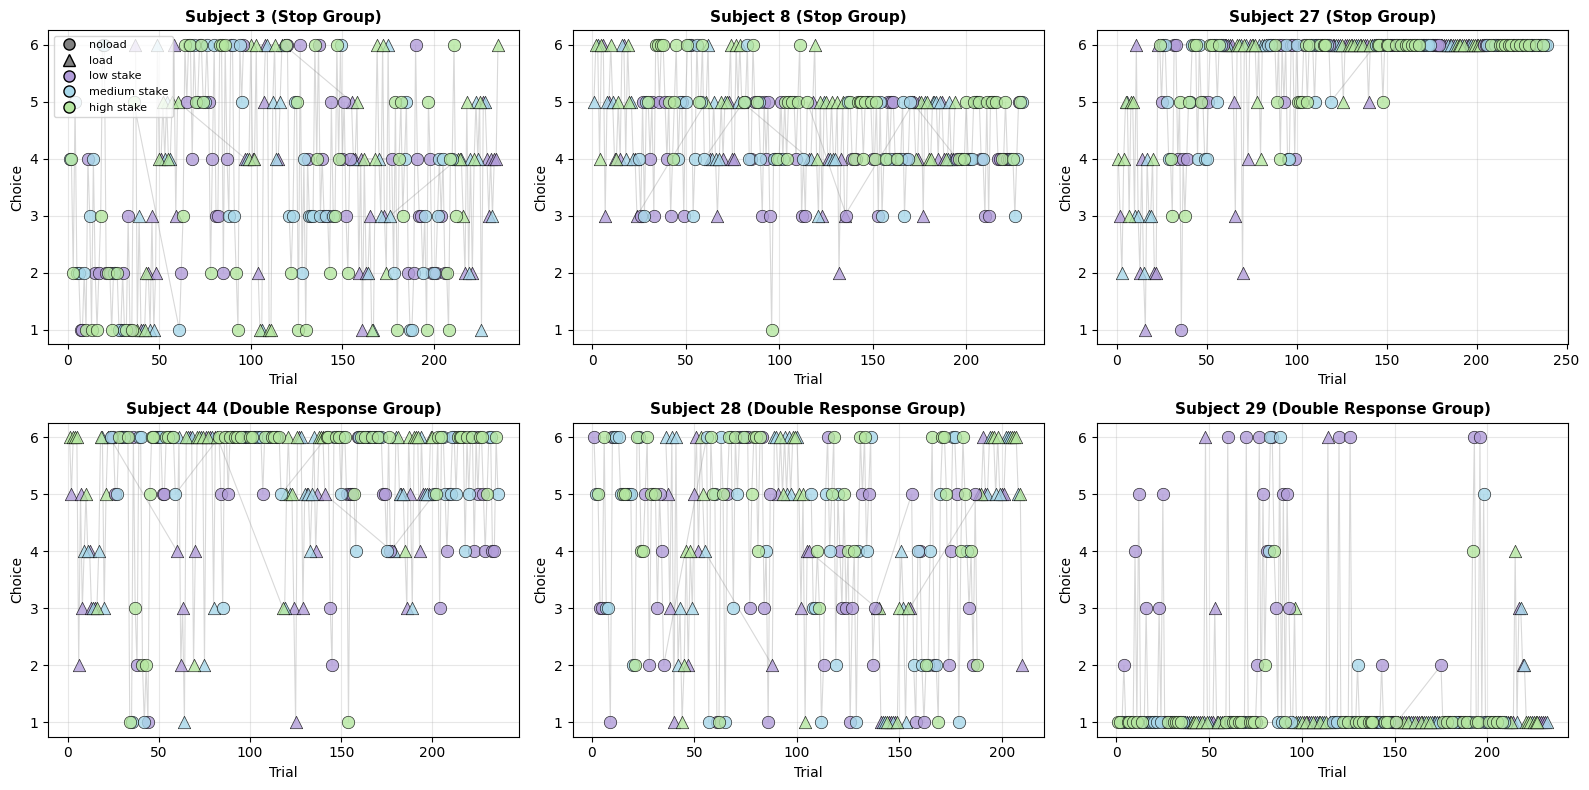

In [ ]:
# Define the function with stake as colour and condition as shape
def subject_by_condition_with_stakes(df, subject_id, group_col='group', trial_col='trial_n', 
                                     choice_col='choice', condition_col='condition',
                                     stake_col='stake'):
    """Plot a single subject's choices with shapes for condition and colors for stakes"""
    
    subject_data = df[df['subject'] == subject_id].sort_values(trial_col)
    group = subject_data[group_col].iloc[0]
    
    fig, ax = plt.subplots(figsize=(14, 4))
    
    # Marker shapes for conditions
    condition_markers = {'load': '^', 'noload': 'o'}  # triangle, circle
    
    # Colours for stakes
    stake_colors = {'low': '#B19CD9', 'medium': '#A8D8EA', 'high': '#B5E7A0'}
    
    # Plot each combination of condition and stake
    for condition in ['load', 'noload']:
        cond_data = subject_data[subject_data[condition_col] == condition]
        
        for stake in ['low', 'medium', 'high']:
            stake_data = cond_data[cond_data[stake_col] == stake]
            if len(stake_data) > 0:
                ax.scatter(stake_data[trial_col], stake_data[choice_col],
                          marker=condition_markers[condition], s=80,
                          color=stake_colors[stake], alpha=0.8, 
                          edgecolors='black', linewidths=0.5, zorder=3)
        
        # Connect all points for this condition with a thin line
        ax.plot(cond_data[trial_col], cond_data[choice_col], 
               '-', color='gray', linewidth=0.8, alpha=0.3, zorder=1)
    
    # Create custom legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='gray', marker='o', linestyle='', markersize=8, 
               markerfacecolor='gray', label='noload'),
        Line2D([0], [0], color='gray', marker='^', linestyle='', markersize=8, 
               markerfacecolor='gray', label='load'),
        Line2D([0], [0], color='white', marker='o', linestyle='', markersize=8, 
               markerfacecolor='#B19CD9', markeredgecolor='black', label='low stake'),
        Line2D([0], [0], color='white', marker='o', linestyle='', markersize=8, 
               markerfacecolor='#A8D8EA', markeredgecolor='black', label='medium stake'),
        Line2D([0], [0], color='white', marker='o', linestyle='', markersize=8, 
               markerfacecolor='#B5E7A0', markeredgecolor='black', label='high stake')
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=9)
    
    ax.set_xlabel('Trial', fontsize=11)
    ax.set_ylabel('Choice', fontsize=11)
    ax.set_title(f'Subject {subject_id} - {group} group', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    return fig, ax

# Setting seed for reproducibility
np.random.seed(41)  

# Randomly sampling 3 subjects from each group
subjects_per_group = 3
interesting_subjects = []

for group in df['group'].unique()[:2]:  # Assuming 2 groups
    group_subjects = df[df['group'] == group]['subject'].unique()
    random_subjects = np.random.choice(group_subjects, size=subjects_per_group, replace=False)
    interesting_subjects.extend(random_subjects)

print(f"Randomly selected subjects: {interesting_subjects}")

# Create the figure ONCE
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# Marker shapes for conditions
condition_markers = {'load': '^', 'noload': 'o'}  # triangle for load, circle for noload

# Colors for stakes (pastel purple, blue, green)
stake_colors = {'low': '#B19CD9', 'medium': '#A8D8EA', 'high': '#B5E7A0'}

for idx, subject in enumerate(interesting_subjects):
    row = idx // 3
    col = idx % 3
    
    subject_data = df[df['subject'] == subject].sort_values('trial_n')
    group = subject_data['group'].iloc[0]
    
    # Plot each combination of condition and stake
    for condition in ['load', 'noload']:
        cond_data = subject_data[subject_data['condition'] == condition]
        
        for stake in ['low', 'medium', 'high']:
            stake_data = cond_data[cond_data['stake'] == stake]
            if len(stake_data) > 0:
                axes[row, col].scatter(stake_data['trial_n'], stake_data['choice'],
                                      marker=condition_markers[condition], s=80,
                                      color=stake_colors[stake], alpha=0.8,
                                      edgecolors='black', linewidths=0.5, zorder=3)
        
        # Connect all points for this condition with a thin line
        axes[row, col].plot(cond_data['trial_n'], cond_data['choice'], 
                           '-', color='gray', linewidth=0.8, alpha=0.3, zorder=1)
    
    axes[row, col].set_title(
    f"Subject {subject} "
    f"({'Stop' if group == "bSTOP" else 'Double Response'} Group)",
    fontsize=11,
    fontweight='bold')
    axes[row, col].set_xlabel('Trial', fontsize=10)
    axes[row, col].set_ylabel('Choice', fontsize=10)
    axes[row, col].grid(True, alpha=0.3)
    
    # Add legend only to first subplot
    if idx == 0:
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='gray', marker='o', linestyle='', markersize=8, 
                   markerfacecolor='gray', markeredgecolor='black', label='noload'),
            Line2D([0], [0], color='gray', marker='^', linestyle='', markersize=8, 
                   markerfacecolor='gray', markeredgecolor='black', label='load'),
            Line2D([0], [0], color='white', marker='o', linestyle='', markersize=8, 
                   markerfacecolor='#B19CD9', markeredgecolor='black', label='low stake'),
            Line2D([0], [0], color='white', marker='o', linestyle='', markersize=8, 
                   markerfacecolor='#A8D8EA', markeredgecolor='black', label='medium stake'),
            Line2D([0], [0], color='white', marker='o', linestyle='', markersize=8, 
                   markerfacecolor='#B5E7A0', markeredgecolor='black', label='high stake')
        ]
        axes[row, col].legend(handles=legend_elements, loc='best', fontsize=8)

plt.tight_layout()
plt.savefig('individual_subjects_with_stakes.png', dpi=300, bbox_inches='tight')
plt.savefig('individual_subjects_with_stakes.pdf', bbox_inches='tight')
plt.show()

3 subjects from each group with separate load/noload plots and win/loss colours

Selected subjects: [np.int64(3), np.int64(8), np.int64(27), np.int64(44), np.int64(28), np.int64(29)]


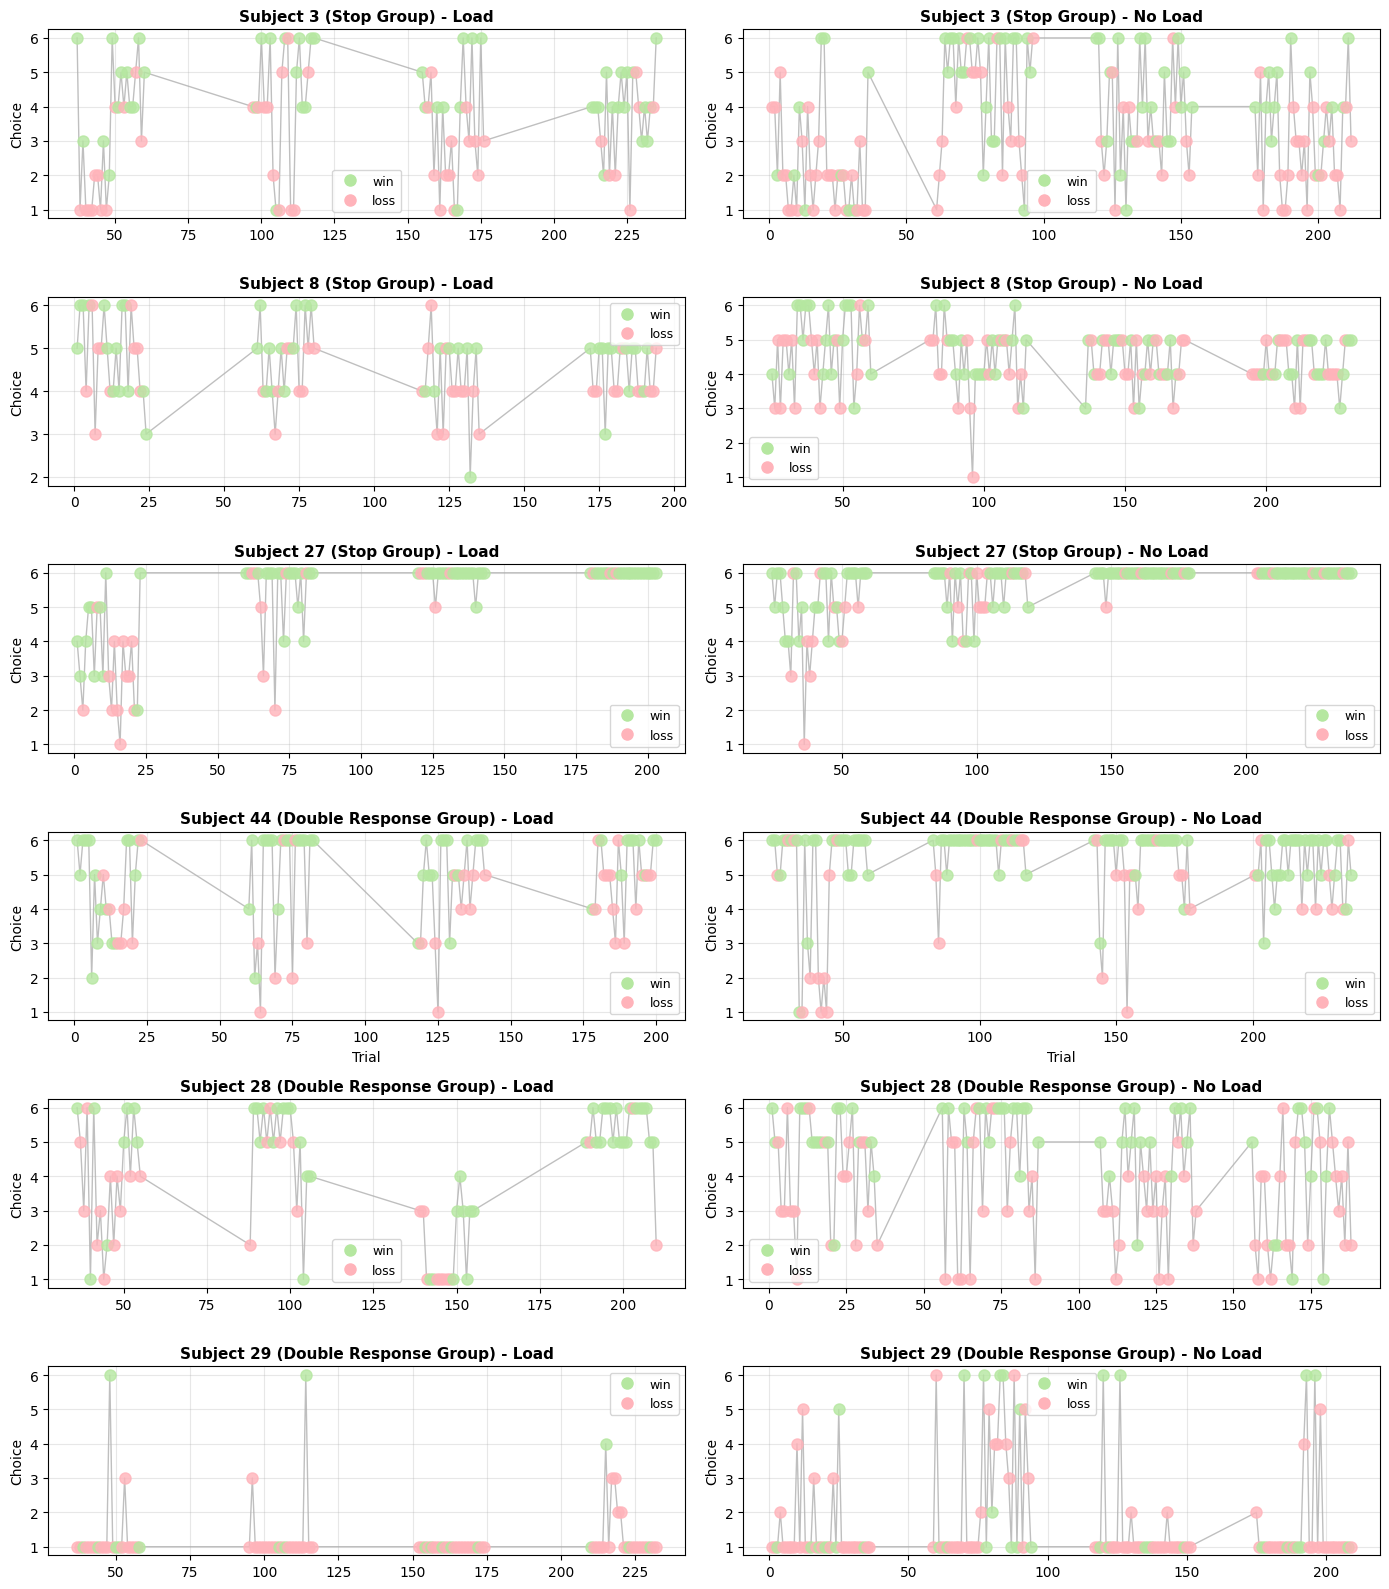

In [ ]:
# Set random seed for reproducibility 
np.random.seed(41)  

# Select 3 random subjects from each group
subjects_to_plot = []
for group in df['group'].unique()[:2]:
    group_subjects = df[df['group'] == group]['subject'].unique()
    random_subjects = np.random.choice(group_subjects, size=3, replace=False)
    subjects_to_plot.extend(random_subjects)

print(f"Selected subjects: {subjects_to_plot}")

# Create a 4x2 grid (4 subjects x 2 conditions)
fig, axes = plt.subplots(6, 2, figsize=(14, 16))

# colors for wins and losses
color_win = '#B5E7A0' 
color_loss = '#FFB3BA'  

for subj_idx, subject in enumerate(subjects_to_plot):
    subject_data = df[df['subject'] == subject].sort_values('trial_n')
    group = subject_data['group'].iloc[0]
    
    # Plot load condition (left column)
    ax_load = axes[subj_idx, 0]
    load_data = subject_data[subject_data['condition'] == 'load'].copy()
    
    if len(load_data) > 0:
        # Color each point based on outcome
        for _, row in load_data.iterrows():
            color = color_win if row['outcome'] == 'win' else color_loss
            ax_load.plot(row['trial_n'], row['choice'], 'o', 
                        color=color, markersize=8, alpha=0.8)
        
        # Add connecting lines
        ax_load.plot(load_data['trial_n'], load_data['choice'], 
                    '-', color='gray', linewidth=1, alpha=0.5, zorder=0)
        
        # Create legend
        ax_load.plot([], [], 'o', color=color_win, markersize=8, label='win')
        ax_load.plot([], [], 'o', color=color_loss, markersize=8, label='loss')
    
    
    ax_load.set_title(
    f"Subject {subject} "
    f"({'Stop' if group == "bSTOP" else 'Double Response'} Group) - Load",
    fontsize=11,
    fontweight='bold')

    ax_load.set_ylabel('Choice', fontsize=10)
    if subj_idx == 3:
        ax_load.set_xlabel('Trial', fontsize=10)
    ax_load.legend(loc='best', fontsize=9)
    ax_load.grid(True, alpha=0.3)
    
    # Plot noload condition (right column)
    ax_noload = axes[subj_idx, 1]
    noload_data = subject_data[subject_data['condition'] == 'noload'].copy()
    
    if len(noload_data) > 0:
        # Color each point based on outcome
        for _, row in noload_data.iterrows():
            color = color_win if row['outcome'] == 'win' else color_loss
            ax_noload.plot(row['trial_n'], row['choice'], 'o', 
                          color=color, markersize=8, alpha=0.8)
        
        # Add connecting lines
        ax_noload.plot(noload_data['trial_n'], noload_data['choice'], 
                      '-', color='gray', linewidth=1, alpha=0.5, zorder=0)
        
        # Create legend
        ax_noload.plot([], [], 'o', color=color_win, markersize=8, label='win')
        ax_noload.plot([], [], 'o', color=color_loss, markersize=8, label='loss')
    
    
    ax_noload.set_title(
    f"Subject {subject} "
    f"({'Stop' if group == "bSTOP" else 'Double Response'} Group) - No Load",
    fontsize=11,
    fontweight='bold')

    ax_noload.set_ylabel('Choice', fontsize=10)
    if subj_idx == 3:
        ax_noload.set_xlabel('Trial', fontsize=10)
    ax_noload.legend(loc='best', fontsize=9)
    ax_noload.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('subjects_load_noload_outcomes.png', dpi=300, bbox_inches='tight')
plt.savefig('subjects_load_noload_outcomes.pdf', bbox_inches='tight')
plt.show()

Plotting how likely subjects are (on average) to stick with the same choice

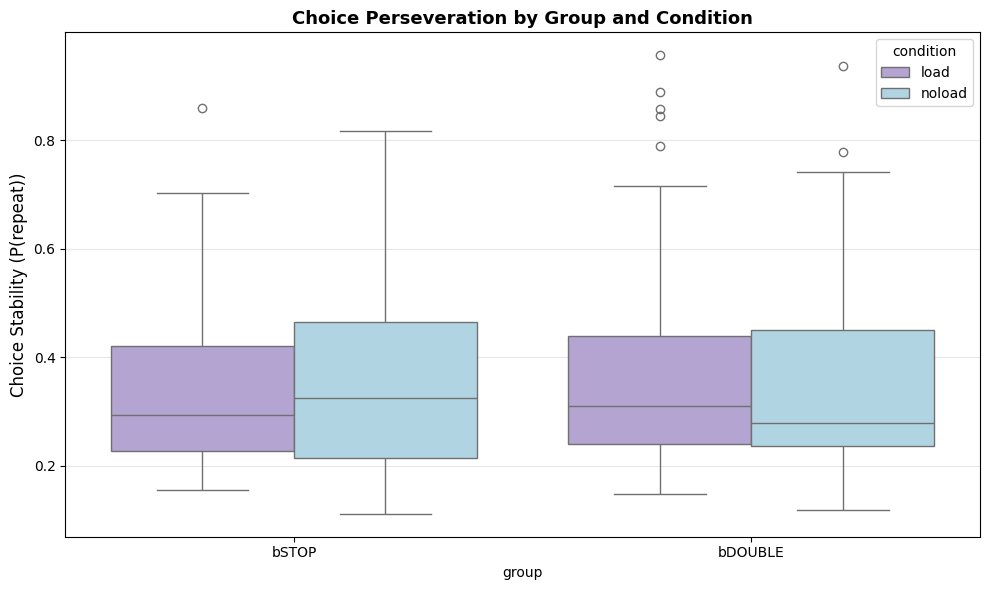


Mean stability by group and condition:
                   count      mean       std       min       25%       50%  \
group   condition                                                            
bDOUBLE load        32.0  0.396064  0.236640  0.147727  0.239362  0.310259   
        noload      32.0  0.366506  0.205582  0.118881  0.236563  0.278535   
bSTOP   load        32.0  0.351956  0.170148  0.155556  0.226306  0.293497   
        noload      32.0  0.352447  0.175327  0.111111  0.213906  0.325065   

                        75%       max  
group   condition                      
bDOUBLE load       0.439428  0.956989  
        noload     0.449301  0.937063  
bSTOP   load       0.421223  0.858974  
        noload     0.464112  0.817518  


In [ ]:
def calculate_choice_stability(df, subject_col='subject', trial_col='trial_n', 
                                choice_col='choice', condition_col='condition', group_col='group'):
    """Calculate the probability of repeating the same choice"""
    
    results = []
    
    for subject in df[subject_col].unique():
        subj_data = df[df[subject_col] == subject].sort_values(trial_col).copy()
        group = subj_data[group_col].iloc[0]
        
        for condition in ['load', 'noload']:
            cond_data = subj_data[subj_data[condition_col] == condition].copy()
            
            if len(cond_data) > 1:
                # Did they repeat the same choice?
                cond_data['same_as_previous'] = (cond_data[choice_col] == cond_data[choice_col].shift(1))
                
                results.append({
                    'subject': subject,
                    'group': group,
                    'condition': condition,
                    'stability': cond_data['same_as_previous'].mean(),
                    'n_trials': len(cond_data) - 1
                })
    
    return pd.DataFrame(results)

stability_df = calculate_choice_stability(df)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=stability_df, x='group', y='stability', hue='condition', ax=ax, palette={'load': '#B19CD9', 'noload': '#A8D8EA'})
ax.set_ylabel('Choice Stability (P(repeat))', fontsize=12)
ax.set_title('Choice Perseveration by Group and Condition', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('choice_stability.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nMean stability by group and condition:")
print(stability_df.groupby(['group', 'condition'])['stability'].describe())

Plotting the probabilities of win-stay and lose-shift behaviours in subjects

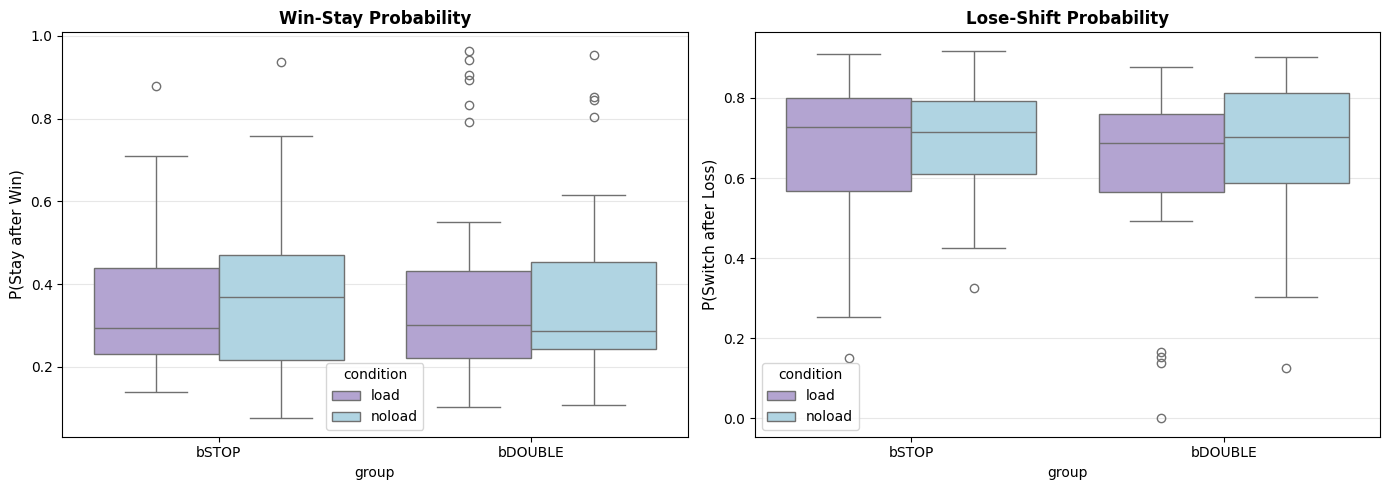


Win-Stay / Lose-Shift by group and condition:
                   win_stay  lose_shift
group   condition                      
bDOUBLE load       0.389680    0.625257
        noload     0.377678    0.671864
bSTOP   load       0.363236    0.669730
        noload     0.375778    0.688388


In [ ]:
def calculate_win_stay_lose_shift(df, subject_col='subject', trial_col='trial_n', 
                                   choice_col='choice', outcome_col='outcome', 
                                   condition_col='condition', group_col='group'):
    """Calculate win-stay and lose-shift probabilities"""
    
    results = []
    
    for subject in df[subject_col].unique():
        subj_data = df[df[subject_col] == subject].sort_values(trial_col).copy()
        group = subj_data[group_col].iloc[0]
        
        # Create lagged variables
        subj_data['prev_choice'] = subj_data[choice_col].shift(1)
        subj_data['prev_outcome'] = subj_data[outcome_col].shift(1)
        subj_data['stayed'] = (subj_data[choice_col] == subj_data['prev_choice'])
        
        for condition in ['load', 'noload']:
            cond_data = subj_data[subj_data[condition_col] == condition].dropna(subset=['prev_outcome'])
            
            if len(cond_data) > 0:
                # Win-stay: after a win, did they repeat?
                after_win = cond_data[cond_data['prev_outcome'] == 'win']
                win_stay = after_win['stayed'].mean() if len(after_win) > 0 else np.nan
                
                # Lose-shift: after a loss, did they switch?
                after_loss = cond_data[cond_data['prev_outcome'] == 'loss']
                lose_shift = (1 - after_loss['stayed'].mean()) if len(after_loss) > 0 else np.nan
                
                results.append({
                    'subject': subject,
                    'group': group,
                    'condition': condition,
                    'win_stay': win_stay,
                    'lose_shift': lose_shift,
                    'n_wins': len(after_win),
                    'n_losses': len(after_loss)
                })
    
    return pd.DataFrame(results)

wsls_df = calculate_win_stay_lose_shift(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Win-stay
sns.boxplot(data=wsls_df, x='group', y='win_stay', hue='condition', ax=axes[0], 
            palette={'load': '#B19CD9', 'noload': '#A8D8EA'})
axes[0].set_ylabel('P(Stay after Win)', fontsize=11)
axes[0].set_title('Win-Stay Probability', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Lose-shift
sns.boxplot(data=wsls_df, x='group', y='lose_shift', hue='condition', ax=axes[1], 
            palette={'load': '#B19CD9', 'noload': '#A8D8EA'})
axes[1].set_ylabel('P(Switch after Loss)', fontsize=11)
axes[1].set_title('Lose-Shift Probability', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('win_stay_lose_shift.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nWin-Stay / Lose-Shift by group and condition:")
print(wsls_df.groupby(['group', 'condition'])[['win_stay', 'lose_shift']].mean())

Plotting switching behaviour going into and out of load blocks


Fixed switch rates around transitions:
                         count      mean       std  min       25%       50%  \
group   transition_type                                                       
bDOUBLE into_load        112.0  0.619048  0.324530  0.0  0.500000  0.666667   
        out_of_load      112.0  0.636905  0.301161  0.0  0.333333  0.666667   
bSTOP   into_load        112.0  0.636905  0.280510  0.0  0.500000  0.666667   
        out_of_load      112.0  0.630952  0.282478  0.0  0.500000  0.666667   

                              75%  max  
group   transition_type                 
bDOUBLE into_load        0.833333  1.0  
        out_of_load      0.833333  1.0  
bSTOP   into_load        0.833333  1.0  
        out_of_load      0.833333  1.0  


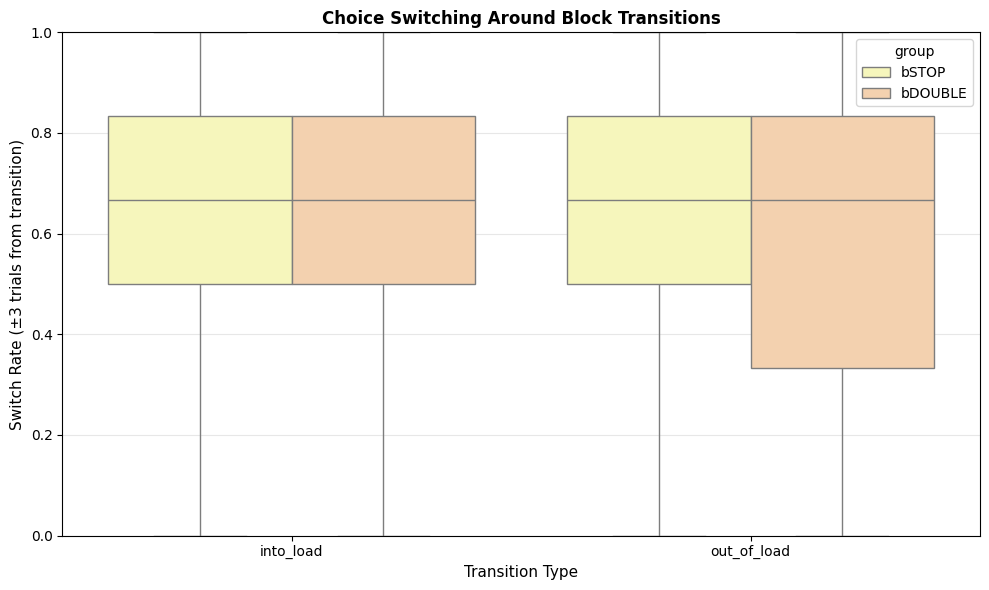

In [ ]:
def analyze_block_transitions_fixed(df, subject_col='subject', trial_col='trial_n', 
                                   choice_col='choice', condition_col='condition', 
                                   group_col='group', window=3):
    """Analyze behaviour in a window around block transitions"""
    
    results = []
    
    for subject in df[subject_col].unique():
        subj_data = df[df[subject_col] == subject].sort_values(trial_col).copy()
        group = subj_data[group_col].iloc[0]
        
        # Reset index to avoid issues
        subj_data = subj_data.reset_index(drop=True)
        
        # Detect transitions
        subj_data['prev_condition'] = subj_data[condition_col].shift(1)
        subj_data['transition'] = (subj_data[condition_col] != subj_data['prev_condition'])
        
        transition_indices = subj_data[subj_data['transition'] & subj_data['prev_condition'].notna()].index
        
        for idx in transition_indices:
            trans_type = 'into_load' if subj_data.loc[idx, condition_col] == 'load' else 'out_of_load'
            
            # Get window indices (not trial numbers)
            start_idx = max(0, idx - window)
            end_idx = min(len(subj_data) - 1, idx + window)
            
            window_data = subj_data.iloc[start_idx:end_idx + 1].copy()
            
            if len(window_data) > 1:
                # Calculate switches within this window
                window_data = window_data.sort_values(trial_col).reset_index(drop=True)
                window_data['switched'] = (window_data[choice_col] != window_data[choice_col].shift(1))
                
                # Count switches (excluding first trial which has no previous)
                n_switches = window_data['switched'].iloc[1:].sum()
                n_comparisons = len(window_data) - 1
                
                results.append({
                    'subject': subject,
                    'group': group,
                    'transition_type': trans_type,
                    'switch_rate': n_switches / n_comparisons if n_comparisons > 0 else np.nan,
                    'n_switches': n_switches,
                    'n_comparisons': n_comparisons,
                    'window_size': len(window_data)
                })
    
    return pd.DataFrame(results)

# Run the fixed version
transition_df_fixed = analyze_block_transitions_fixed(df, window=3)

print("\nFixed switch rates around transitions:")
print(transition_df_fixed.groupby(['group', 'transition_type'])['switch_rate'].describe())

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=transition_df_fixed, x='transition_type', y='switch_rate', hue='group', ax=ax,
            palette = {'bSTOP': '#FFFFB3', 'bDOUBLE': '#FFD1A3'})
ax.set_ylabel('Switch Rate (±3 trials from transition)', fontsize=11)
ax.set_xlabel('Transition Type', fontsize=11)
ax.set_title('Choice Switching Around Block Transitions', fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)  # Force 0-1 range
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('transition_dynamics_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

Plotting the metrics from above over trials

In [ ]:
np.random.seed(41)  
subjects_to_track = []
for group in df['group'].unique()[:2]:
    group_subjects = df[df['group'] == group]['subject'].unique()
    random_subjects = np.random.choice(group_subjects, size=3, replace=False)
    subjects_to_track.extend(random_subjects)

print(f"Tracking subjects: {subjects_to_track}")

# Function to calculate metrics in sliding windows
def calculate_metrics_over_time(df, subjects, window_size=20, step_size=5,
                                subject_col='subject', trial_col='trial_n',
                                choice_col='choice', outcome_col='outcome',
                                group_col='group'):
    """Calculate all three metrics across the experiment"""
    
    results = []
    
    for subject in subjects:
        subj_data = df[df[subject_col] == subject].sort_values(trial_col).copy()
        group = subj_data[group_col].iloc[0]
        
        # Sliding window
        for start_idx in range(0, len(subj_data) - window_size + 1, step_size):
            window_data = subj_data.iloc[start_idx:start_idx + window_size].copy()
            
            # Get middle trial number for plotting
            middle_trial = window_data[trial_col].iloc[len(window_data)//2]
            
            # 1. Choice Stability
            window_data['same_as_previous'] = (window_data[choice_col] == window_data[choice_col].shift(1))
            stability = window_data['same_as_previous'].iloc[1:].mean()
            
            # 2. Win-Stay / Lose-Shift
            window_data['prev_choice'] = window_data[choice_col].shift(1)
            window_data['prev_outcome'] = window_data[outcome_col].shift(1)
            window_data['stayed'] = (window_data[choice_col] == window_data['prev_choice'])
            
            after_win = window_data[window_data['prev_outcome'] == 'win']
            win_stay = after_win['stayed'].mean() if len(after_win) > 0 else np.nan
            
            after_loss = window_data[window_data['prev_outcome'] == 'loss']
            lose_shift = (1 - after_loss['stayed'].mean()) if len(after_loss) > 0 else np.nan
            
            # 3. Switch Rate (overall in this window)
            switches = (window_data[choice_col] != window_data[choice_col].shift(1)).sum()
            switch_rate = switches / (len(window_data) - 1)
            
            results.append({
                'subject': subject,
                'group': group,
                'trial': middle_trial,
                'stability': stability,
                'win_stay': win_stay,
                'lose_shift': lose_shift,
                'switch_rate': switch_rate
            })
    
    return pd.DataFrame(results)

# Calculate metrics over time
time_metrics = calculate_metrics_over_time(df, subjects_to_track, window_size=20, step_size=5)

print("\nMetrics over time calculated!")
print(time_metrics.head())

Tracking subjects: [np.int64(3), np.int64(8), np.int64(27), np.int64(44), np.int64(28), np.int64(29)]

Metrics over time calculated!
   subject  group  trial  stability  win_stay  lose_shift  switch_rate
0        3  bSTOP     11   0.210526  0.200000    0.785714     0.842105
1        3  bSTOP     16   0.210526  0.200000    0.785714     0.842105
2        3  bSTOP     21   0.315789  0.333333    0.692308     0.736842
3        3  bSTOP     26   0.421053  0.600000    0.642857     0.631579
4        3  bSTOP     31   0.368421  0.333333    0.615385     0.684211


Individual subjects' 3 metrics over time

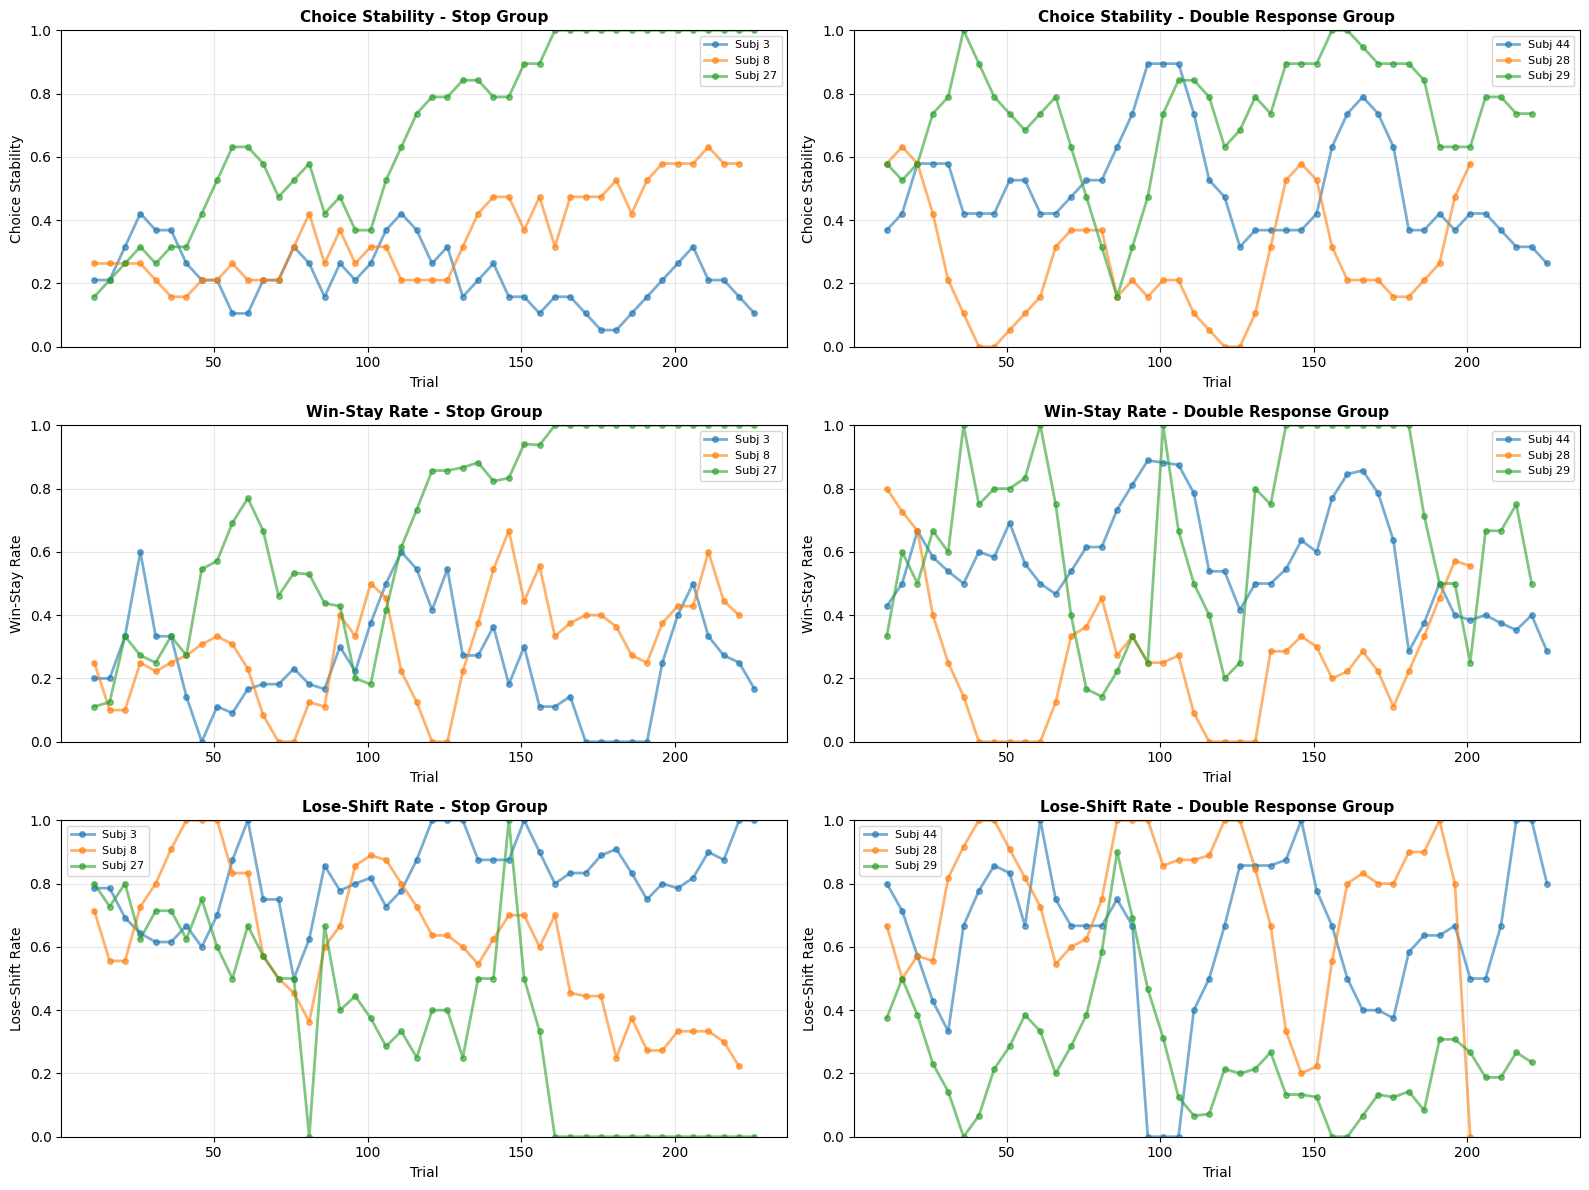

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

metrics = ['stability', 'win_stay', 'lose_shift']
metric_labels = ['Choice Stability', 'Win-Stay Rate', 'Lose-Shift Rate']
colors_by_group = {}

for col_idx, group in enumerate(df['group'].unique()[:2]):
    group_subjects = [s for s in subjects_to_track if 
                     df[df['subject'] == s]['group'].iloc[0] == group]
    
    for row_idx, (metric, label) in enumerate(zip(metrics, metric_labels)):
        ax = axes[row_idx, col_idx]
        
        for subject in group_subjects:
            subj_data = time_metrics[time_metrics['subject'] == subject]
            ax.plot(subj_data['trial'], subj_data[metric], 
                   'o-', alpha=0.6, linewidth=2, markersize=4, label=f'Subj {subject}')
        
        ax.set_title(f'{label} - ' f"{'Stop' if group == "bSTOP" else 'Double Response'} Group", fontsize=11, fontweight='bold')
        ax.set_xlabel('Trial', fontsize=10)
        ax.set_ylabel(label, fontsize=10)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8, loc='best')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_over_time_individual.png', dpi=300, bbox_inches='tight')
plt.show()

Group-level trajectories

In [ ]:
# Calculate group-level metrics
def calculate_group_metrics_over_time(df, window_size=20, step_size=5,
                                     subject_col='subject', trial_col='trial_n',
                                     choice_col='choice', outcome_col='outcome',
                                     condition_col='condition', group_col='group'):
    """Calculate metrics over time at the group level"""
    
    all_results = []
    
    for subject in df[subject_col].unique():
        subj_data = df[df[subject_col] == subject].sort_values(trial_col).copy()
        group = subj_data[group_col].iloc[0]
        
        for start_idx in range(0, len(subj_data) - window_size + 1, step_size):
            window_data = subj_data.iloc[start_idx:start_idx + window_size].copy()
            middle_trial = window_data[trial_col].iloc[len(window_data)//2]
            
            # Determine predominant condition in this window
            condition = window_data[condition_col].mode()[0] if len(window_data[condition_col].mode()) > 0 else 'unknown'
            
            # Calculate metrics (same as before)
            window_data['same_as_previous'] = (window_data[choice_col] == window_data[choice_col].shift(1))
            stability = window_data['same_as_previous'].iloc[1:].mean()
            
            window_data['prev_choice'] = window_data[choice_col].shift(1)
            window_data['prev_outcome'] = window_data[outcome_col].shift(1)
            window_data['stayed'] = (window_data[choice_col] == window_data['prev_choice'])
            
            after_win = window_data[window_data['prev_outcome'] == 'win']
            win_stay = after_win['stayed'].mean() if len(after_win) > 0 else np.nan
            
            after_loss = window_data[window_data['prev_outcome'] == 'loss']
            lose_shift = (1 - after_loss['stayed'].mean()) if len(after_loss) > 0 else np.nan
            
            switches = (window_data[choice_col] != window_data[choice_col].shift(1)).sum()
            switch_rate = switches / (len(window_data) - 1)
            
            all_results.append({
                'subject': subject,
                'group': group,
                'trial': middle_trial,
                'condition': condition,
                'stability': stability,
                'win_stay': win_stay,
                'lose_shift': lose_shift,
                'switch_rate': switch_rate
            })
    
    return pd.DataFrame(all_results)

group_time_metrics = calculate_group_metrics_over_time(df, window_size=20, step_size=5)

# Aggregate by group and trial bins
group_time_metrics['trial_bin'] = (group_time_metrics['trial'] // 20) * 20  # Bin trials

group_summary = group_time_metrics.groupby(['group', 'trial_bin', 'condition']).agg({
    'stability': ['mean', 'sem'],
    'win_stay': ['mean', 'sem'],
    'lose_shift': ['mean', 'sem'],
    'switch_rate': ['mean', 'sem']
}).reset_index()

# Flatten column names
group_summary.columns = ['_'.join(col).strip('_') for col in group_summary.columns.values]
group_summary.columns = ['group', 'trial_bin', 'condition', 
                         'stability_mean', 'stability_sem',
                         'win_stay_mean', 'win_stay_sem',
                         'lose_shift_mean', 'lose_shift_sem',
                         'switch_rate_mean', 'switch_rate_sem']

print("\nGroup-level metrics calculated!")
print(group_summary.head())


Group-level metrics calculated!
     group  trial_bin condition  stability_mean  stability_sem  win_stay_mean  \
0  bDOUBLE          0      load        0.347039       0.038605       0.326210   
1  bDOUBLE          0    noload        0.332237       0.031568       0.337317   
2  bDOUBLE         20      load        0.313158       0.051010       0.315590   
3  bDOUBLE         20    noload        0.335283       0.021111       0.330749   
4  bDOUBLE         40      load        0.325216       0.027140       0.328497   

   win_stay_sem  lose_shift_mean  lose_shift_sem  switch_rate_mean  \
0      0.044901         0.651931        0.040640          0.705592   
1      0.039395         0.688045        0.033345          0.720395   
2      0.064347         0.705310        0.049630          0.739474   
3      0.024696         0.692154        0.020355          0.717349   
4      0.029591         0.686816        0.031730          0.727416   

   switch_rate_sem  
0         0.038605  
1         0.03156

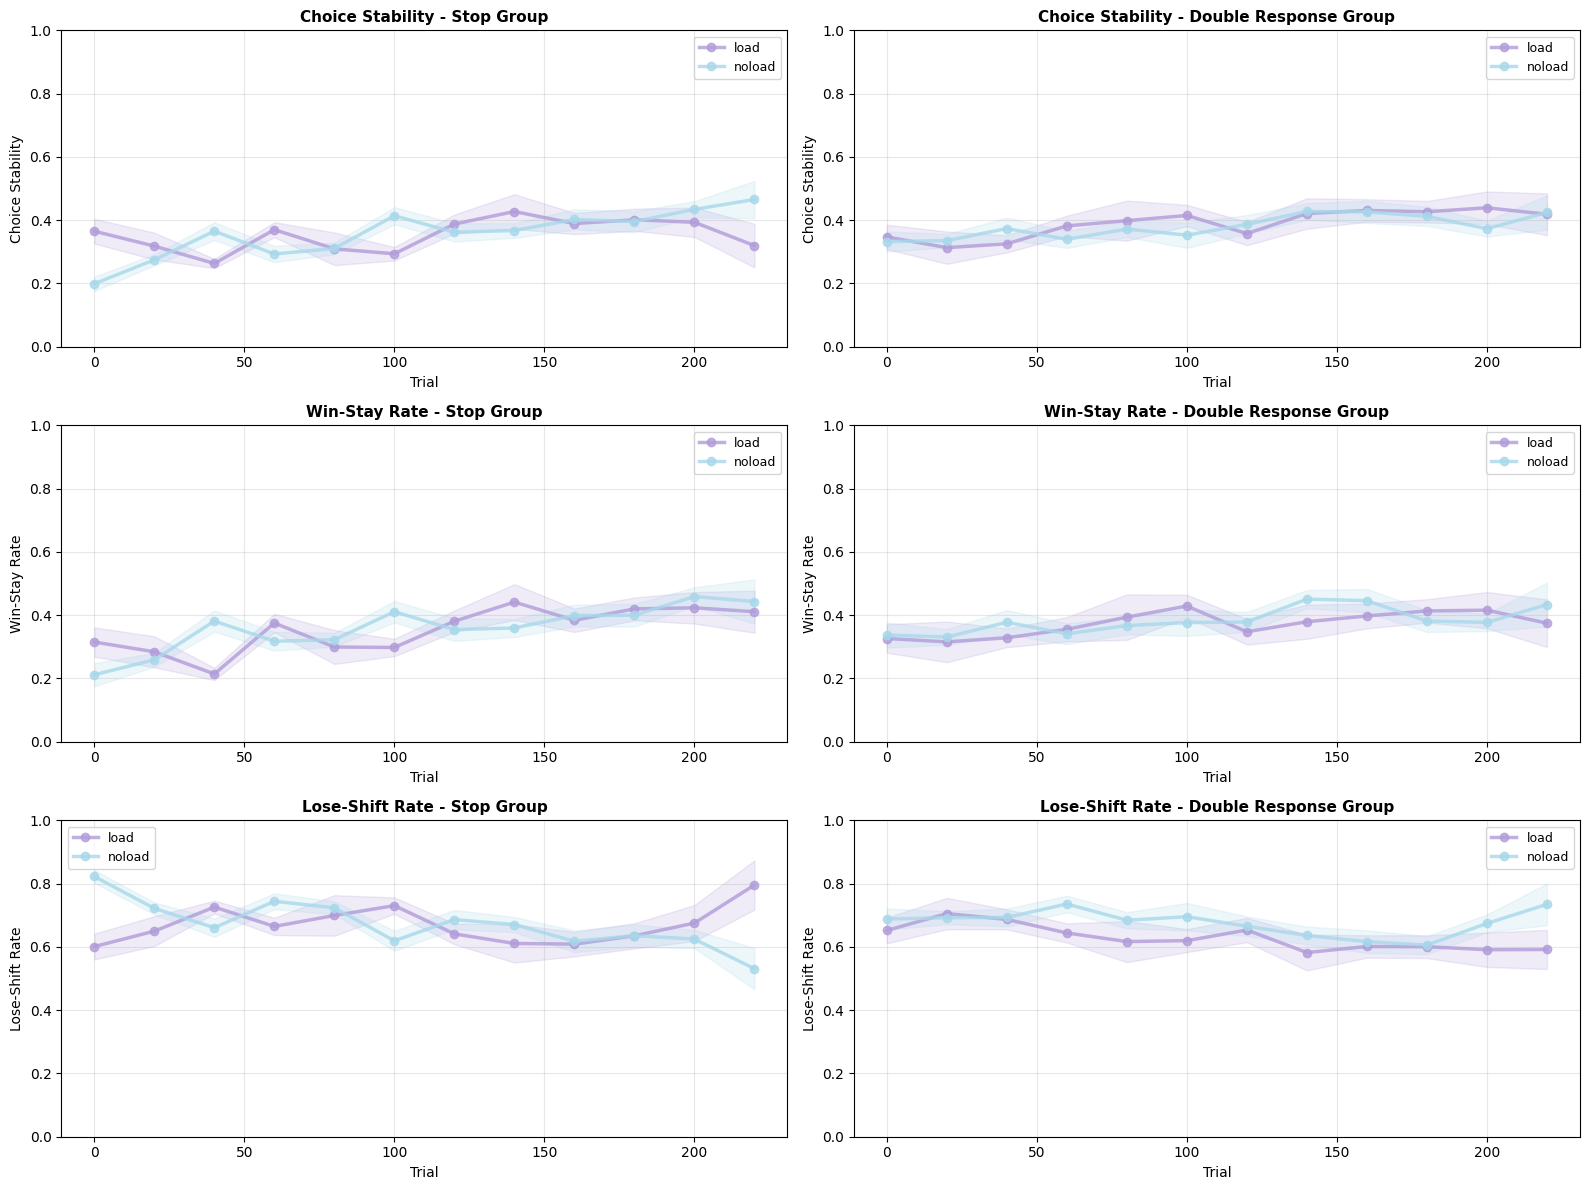

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

metrics = [('stability', 'Choice Stability'), 
           ('win_stay', 'Win-Stay Rate'), 
           ('lose_shift', 'Lose-Shift Rate')]

for col_idx, group in enumerate(df['group'].unique()[:2]):
    group_data = group_summary[group_summary['group'] == group]
    
    for row_idx, (metric, label) in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        
        # Plot by condition
        for condition, color in [('load', '#B19CD9'), ('noload', '#A8D8EA')]:
            cond_data = group_data[group_data['condition'] == condition].sort_values('trial_bin')
            
            if len(cond_data) > 0:
                mean_col = f'{metric}_mean'
                sem_col = f'{metric}_sem'
                
                ax.plot(cond_data['trial_bin'], cond_data[mean_col], 
                       'o-', color=color, linewidth=2.5, markersize=6, 
                       alpha=0.8, label=condition)
                ax.fill_between(cond_data['trial_bin'],
                               cond_data[mean_col] - cond_data[sem_col],
                               cond_data[mean_col] + cond_data[sem_col],
                               color=color, alpha=0.2)
        
        ax.set_title(f'{label} - ' f"{'Stop' if group == "bSTOP" else 'Double Response'} Group", fontsize=11, fontweight='bold')
        ax.set_xlabel('Trial', fontsize=10)
        ax.set_ylabel(label, fontsize=10)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=9, loc='best')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_over_time_group.png', dpi=300, bbox_inches='tight')
plt.show()

3 metrics, per groups

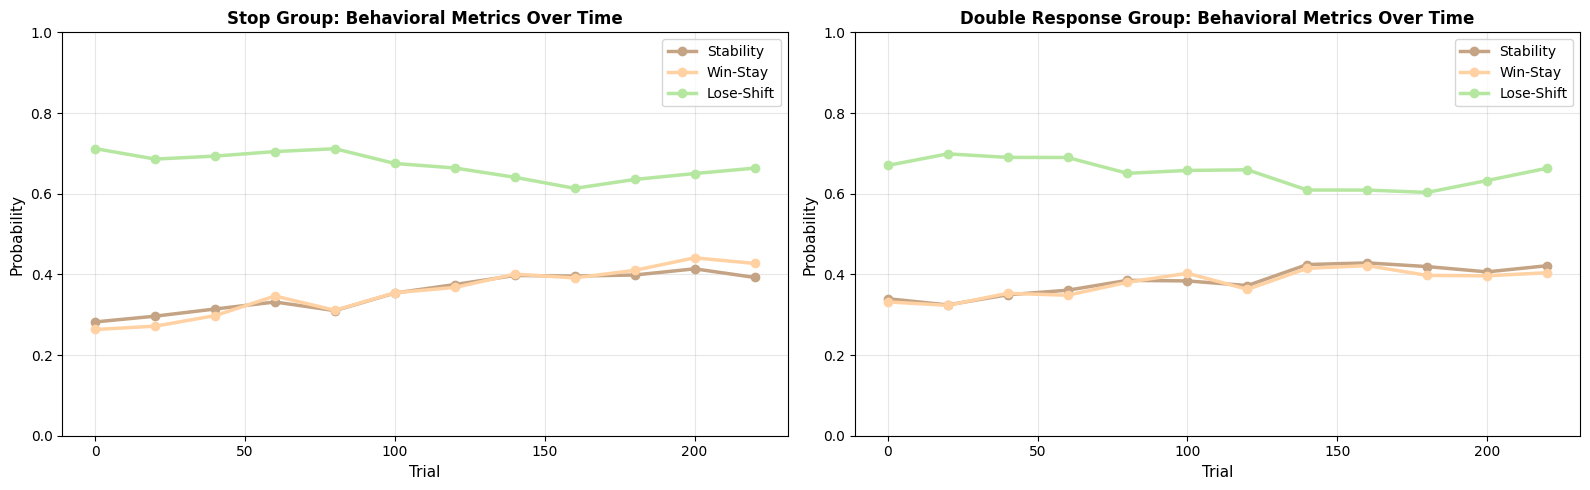

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for col_idx, group in enumerate(df['group'].unique()[:2]):
    ax = axes[col_idx]
    group_data = group_summary[group_summary['group'] == group]
    
    # Combine load and noload for cleaner visualization
    group_avg = group_data.groupby('trial_bin').agg({
        'stability_mean': 'mean',
        'win_stay_mean': 'mean',
        'lose_shift_mean': 'mean'
    }).reset_index()
    
    colors = ['#C4A484', '#FFD1A3', '#B5E7A0']  # pastel yellow, orange, green
    
    ax.plot(group_avg['trial_bin'], group_avg['stability_mean'], 
           'o-', color=colors[0], linewidth=2.5, markersize=6, label='Stability')
    ax.plot(group_avg['trial_bin'], group_avg['win_stay_mean'], 
           'o-', color=colors[1], linewidth=2.5, markersize=6, label='Win-Stay')
    ax.plot(group_avg['trial_bin'], group_avg['lose_shift_mean'], 
           'o-', color=colors[2], linewidth=2.5, markersize=6, label='Lose-Shift')
    
    ax.set_title(f"{'Stop' if group == "bSTOP" else 'Double Response'} Group" f": Behavioral Metrics Over Time", fontsize=12, fontweight='bold')
    ax.set_xlabel('Trial', fontsize=11)
    ax.set_ylabel('Probability', fontsize=11)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('metrics_over_time_combined.png', dpi=300, bbox_inches='tight')
plt.show()

Group level choice preference over time

In [ ]:
def calculate_choice_preference_over_time(df, window_size=20, step_size=5,
                                         subject_col='subject', trial_col='trial_n',
                                         choice_col='choice', condition_col='condition',
                                         group_col='group'):
    """Calculate mean choice value over time"""
    
    all_results = []
    
    for subject in df[subject_col].unique():
        subj_data = df[df[subject_col] == subject].sort_values(trial_col).copy()
        group = subj_data[group_col].iloc[0]
        
        for start_idx in range(0, len(subj_data) - window_size + 1, step_size):
            window_data = subj_data.iloc[start_idx:start_idx + window_size].copy()
            middle_trial = window_data[trial_col].iloc[len(window_data)//2]
            
            # Determine predominant condition in this window
            condition = window_data[condition_col].mode()[0] if len(window_data[condition_col].mode()) > 0 else 'unknown'
            
            # Calculate mean choice in this window
            mean_choice = window_data[choice_col].mean()
            
            all_results.append({
                'subject': subject,
                'group': group,
                'trial': middle_trial,
                'condition': condition,
                'mean_choice': mean_choice
            })
    
    return pd.DataFrame(all_results)

choice_over_time = calculate_choice_preference_over_time(df, window_size=20, step_size=5)

# Aggregate by group and trial bins
choice_over_time['trial_bin'] = (choice_over_time['trial'] // 20) * 20

choice_summary = choice_over_time.groupby(['group', 'trial_bin', 'condition']).agg({
    'mean_choice': ['mean', 'sem']
}).reset_index()

choice_summary.columns = ['group', 'trial_bin', 'condition', 'mean_choice', 'sem_choice']

print("Choice preference over time:")
print(choice_summary.head(20))

Choice preference over time:
      group  trial_bin condition  mean_choice  sem_choice
0   bDOUBLE          0      load     3.712500    0.178592
1   bDOUBLE          0    noload     3.784375    0.195378
2   bDOUBLE         20      load     3.747500    0.224414
3   bDOUBLE         20    noload     3.737037    0.103809
4   bDOUBLE         40      load     3.793284    0.143319
5   bDOUBLE         40    noload     3.818033    0.126297
6   bDOUBLE         60      load     4.000714    0.115284
7   bDOUBLE         60    noload     3.947414    0.158317
8   bDOUBLE         80      load     3.961905    0.277465
9   bDOUBLE         80    noload     4.123364    0.101068
10  bDOUBLE        100      load     3.819118    0.174861
11  bDOUBLE        100    noload     4.090000    0.131537
12  bDOUBLE        120      load     3.807627    0.144800
13  bDOUBLE        120    noload     3.864493    0.150206
14  bDOUBLE        140      load     3.746970    0.237858
15  bDOUBLE        140    noload     3.9621

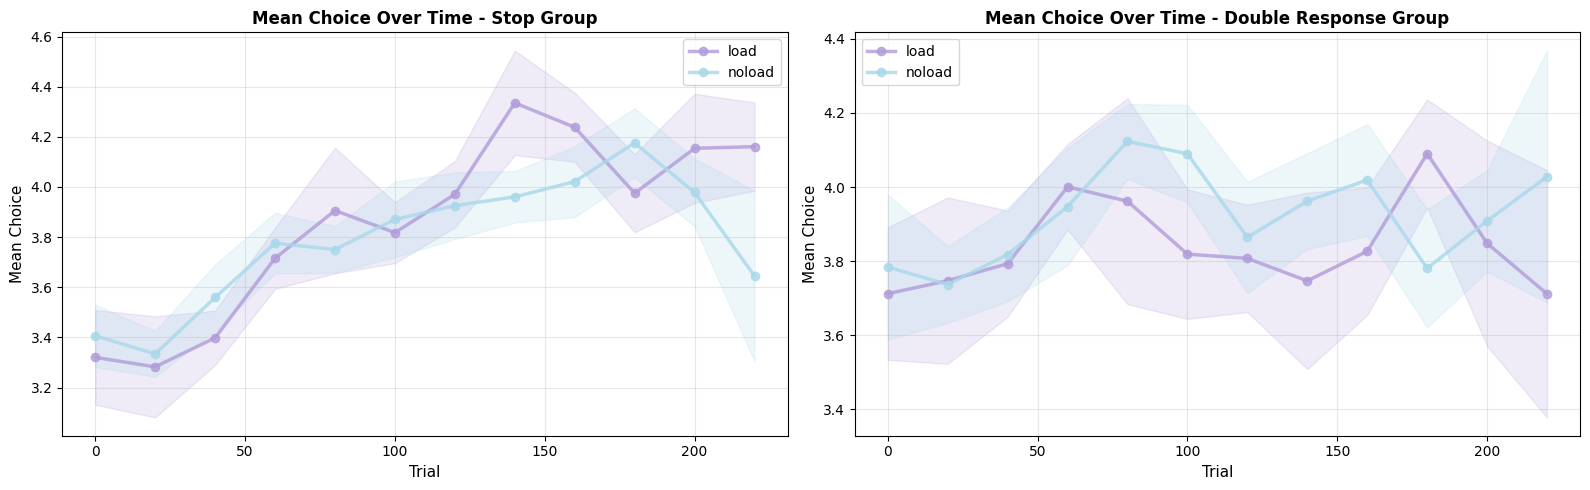

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for col_idx, group in enumerate(df['group'].unique()[:2]):
    ax = axes[col_idx]
    group_data = choice_summary[choice_summary['group'] == group]
    
    # Plot by condition
    for condition, color in [('load', '#B19CD9'), ('noload', '#A8D8EA')]:
        cond_data = group_data[group_data['condition'] == condition].sort_values('trial_bin')
        
        if len(cond_data) > 0:
            ax.plot(cond_data['trial_bin'], cond_data['mean_choice'], 
                   'o-', color=color, linewidth=2.5, markersize=6, 
                   alpha=0.8, label=condition)
            ax.fill_between(cond_data['trial_bin'],
                           cond_data['mean_choice'] - cond_data['sem_choice'],
                           cond_data['mean_choice'] + cond_data['sem_choice'],
                           color=color, alpha=0.2)
    
    ax.set_title(f'Mean Choice Over Time - ' f"{'Stop' if group == "bSTOP" else 'Double Response'} Group", fontsize=12, fontweight='bold')
    ax.set_xlabel('Trial', fontsize=11)
    ax.set_ylabel('Mean Choice', fontsize=11)
    ax.legend(fontsize=10, loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('choice_preference_over_time_by_condition.png', dpi=300, bbox_inches='tight')
plt.show()

Groups on the same plot

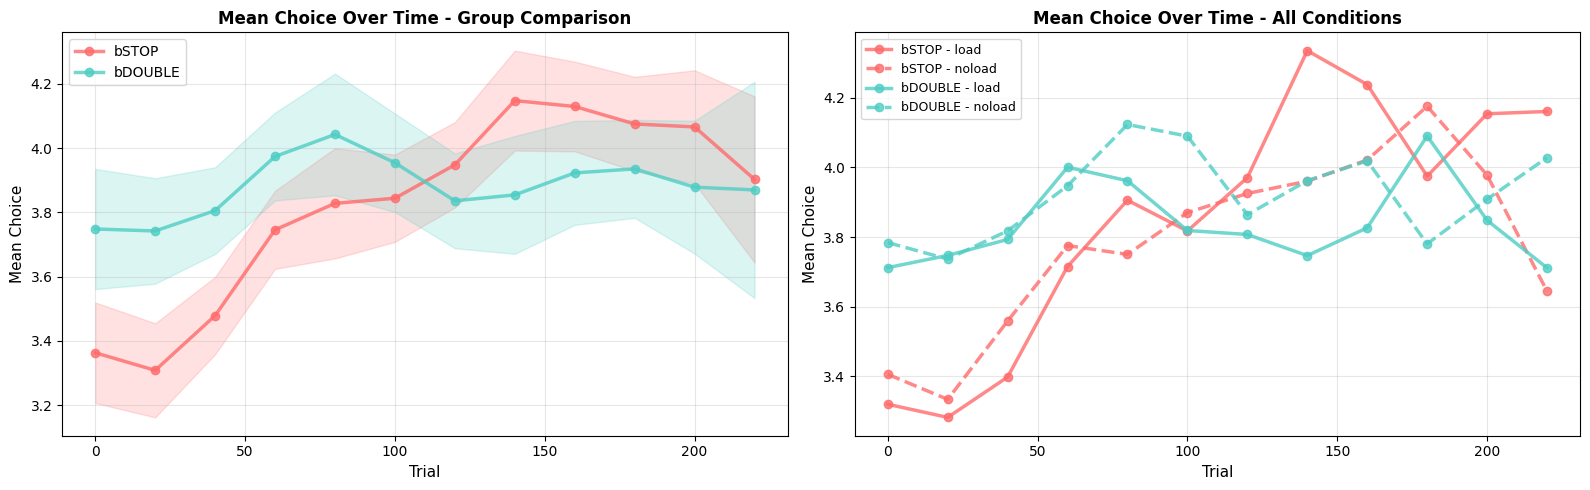

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 2a: Overall (combining conditions)
ax = axes[0]
for group, color in [(df['group'].unique()[0], '#FF6B6B'), 
                     (df['group'].unique()[1], '#4ECDC4')]:
    group_data = choice_summary[choice_summary['group'] == group]
    
    # Average across conditions
    group_avg = group_data.groupby('trial_bin').agg({
        'mean_choice': 'mean',
        'sem_choice': 'mean'
    }).reset_index()
    
    ax.plot(group_avg['trial_bin'], group_avg['mean_choice'], 
           'o-', color=color, linewidth=2.5, markersize=6, 
           alpha=0.8, label=group)
    ax.fill_between(group_avg['trial_bin'],
                   group_avg['mean_choice'] - group_avg['sem_choice'],
                   group_avg['mean_choice'] + group_avg['sem_choice'],
                   color=color, alpha=0.2)

ax.set_title('Mean Choice Over Time - Group Comparison', fontsize=12, fontweight='bold')
ax.set_xlabel('Trial', fontsize=11)
ax.set_ylabel('Mean Choice', fontsize=11)
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)

# Plot 2b: Separate by condition (4 lines total)
ax = axes[1]
for group in df['group'].unique()[:2]:
    group_data = choice_summary[choice_summary['group'] == group]
    
    for condition, style in [('load', '-'), ('noload', '--')]:
        cond_data = group_data[group_data['condition'] == condition].sort_values('trial_bin')
        
        if len(cond_data) > 0:
            color = '#FF6B6B' if group == df['group'].unique()[0] else '#4ECDC4'
            ax.plot(cond_data['trial_bin'], cond_data['mean_choice'], 
                   'o' + style, color=color, linewidth=2.5, markersize=6, 
                   alpha=0.8, label=f'{group} - {condition}')

ax.set_title('Mean Choice Over Time - All Conditions', fontsize=12, fontweight='bold')
ax.set_xlabel('Trial', fontsize=11)
ax.set_ylabel('Mean Choice', fontsize=11)
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('choice_preference_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Calculate proportion of subjects choosing each option over time

def calculate_choice_distribution_over_time(df, window_size=20, step_size=5,
                                           subject_col='subject', trial_col='trial_n',
                                           choice_col='choice', condition_col='condition',
                                           group_col='group'):
    """Calculate proportion of subjects choosing each option over time"""
    
    all_results = []
    
    # Get all unique choices
    all_choices = sorted(df[choice_col].unique())
    
    for subject in df[subject_col].unique():
        subj_data = df[df[subject_col] == subject].sort_values(trial_col).copy()
        group = subj_data[group_col].iloc[0]
        
        for start_idx in range(0, len(subj_data) - window_size + 1, step_size):
            window_data = subj_data.iloc[start_idx:start_idx + window_size].copy()
            middle_trial = window_data[trial_col].iloc[len(window_data)//2]
            
            # Determine predominant condition in this window
            condition = window_data[condition_col].mode()[0] if len(window_data[condition_col].mode()) > 0 else 'unknown'
            
            # Calculate proportion of each choice in this window for this subject
            choice_counts = window_data[choice_col].value_counts()
            total = len(window_data)
            
            for choice in all_choices:
                proportion = choice_counts.get(choice, 0) / total
                
                all_results.append({
                    'subject': subject,
                    'group': group,
                    'trial': middle_trial,
                    'condition': condition,
                    'choice_option': choice,
                    'proportion': proportion
                })
    
    return pd.DataFrame(all_results)

choice_dist_over_time = calculate_choice_distribution_over_time(df, window_size=20, step_size=5)

# Aggregate by group, trial bins, and choice option
choice_dist_over_time['trial_bin'] = (choice_dist_over_time['trial'] // 20) * 20

choice_dist_summary = choice_dist_over_time.groupby(['group', 'trial_bin', 'condition', 'choice_option']).agg({
    'proportion': ['mean', 'sem']
}).reset_index()

choice_dist_summary.columns = ['group', 'trial_bin', 'condition', 'choice_option', 'mean_proportion', 'sem_proportion']

print("Choice distribution over time:")
print(choice_dist_summary.head(20))
print(f"\nAvailable choice options: {sorted(df['choice'].unique())}")

Choice distribution over time:
      group  trial_bin condition  choice_option  mean_proportion  \
0   bDOUBLE          0      load              1         0.101562   
1   bDOUBLE          0      load              2         0.143750   
2   bDOUBLE          0      load              3         0.204687   
3   bDOUBLE          0      load              4         0.218750   
4   bDOUBLE          0      load              5         0.153125   
5   bDOUBLE          0      load              6         0.178125   
6   bDOUBLE          0    noload              1         0.151562   
7   bDOUBLE          0    noload              2         0.118750   
8   bDOUBLE          0    noload              3         0.156250   
9   bDOUBLE          0    noload              4         0.165625   
10  bDOUBLE          0    noload              5         0.182812   
11  bDOUBLE          0    noload              6         0.225000   
12  bDOUBLE         20      load              1         0.105000   
13  bDOUBLE      

In [ ]:
choice_dist_summary.describe()

,trial_bin,choice_option,mean_proportion,sem_proportion
count,288.000000,288.000000,288.000000,288.000000
mean,110.000000,3.500000,0.166667,0.025495
std,69.161227,1.710798,0.056500,0.012815
min,0.000000,1.000000,0.059286,0.009060
25%,55.000000,2.000000,0.126790,0.017071
50%,110.000000,3.500000,0.159330,0.021184
75%,165.000000,5.000000,0.195374,0.030320
max,220.000000,6.000000,0.411765,0.083381


Group comparison for choice options

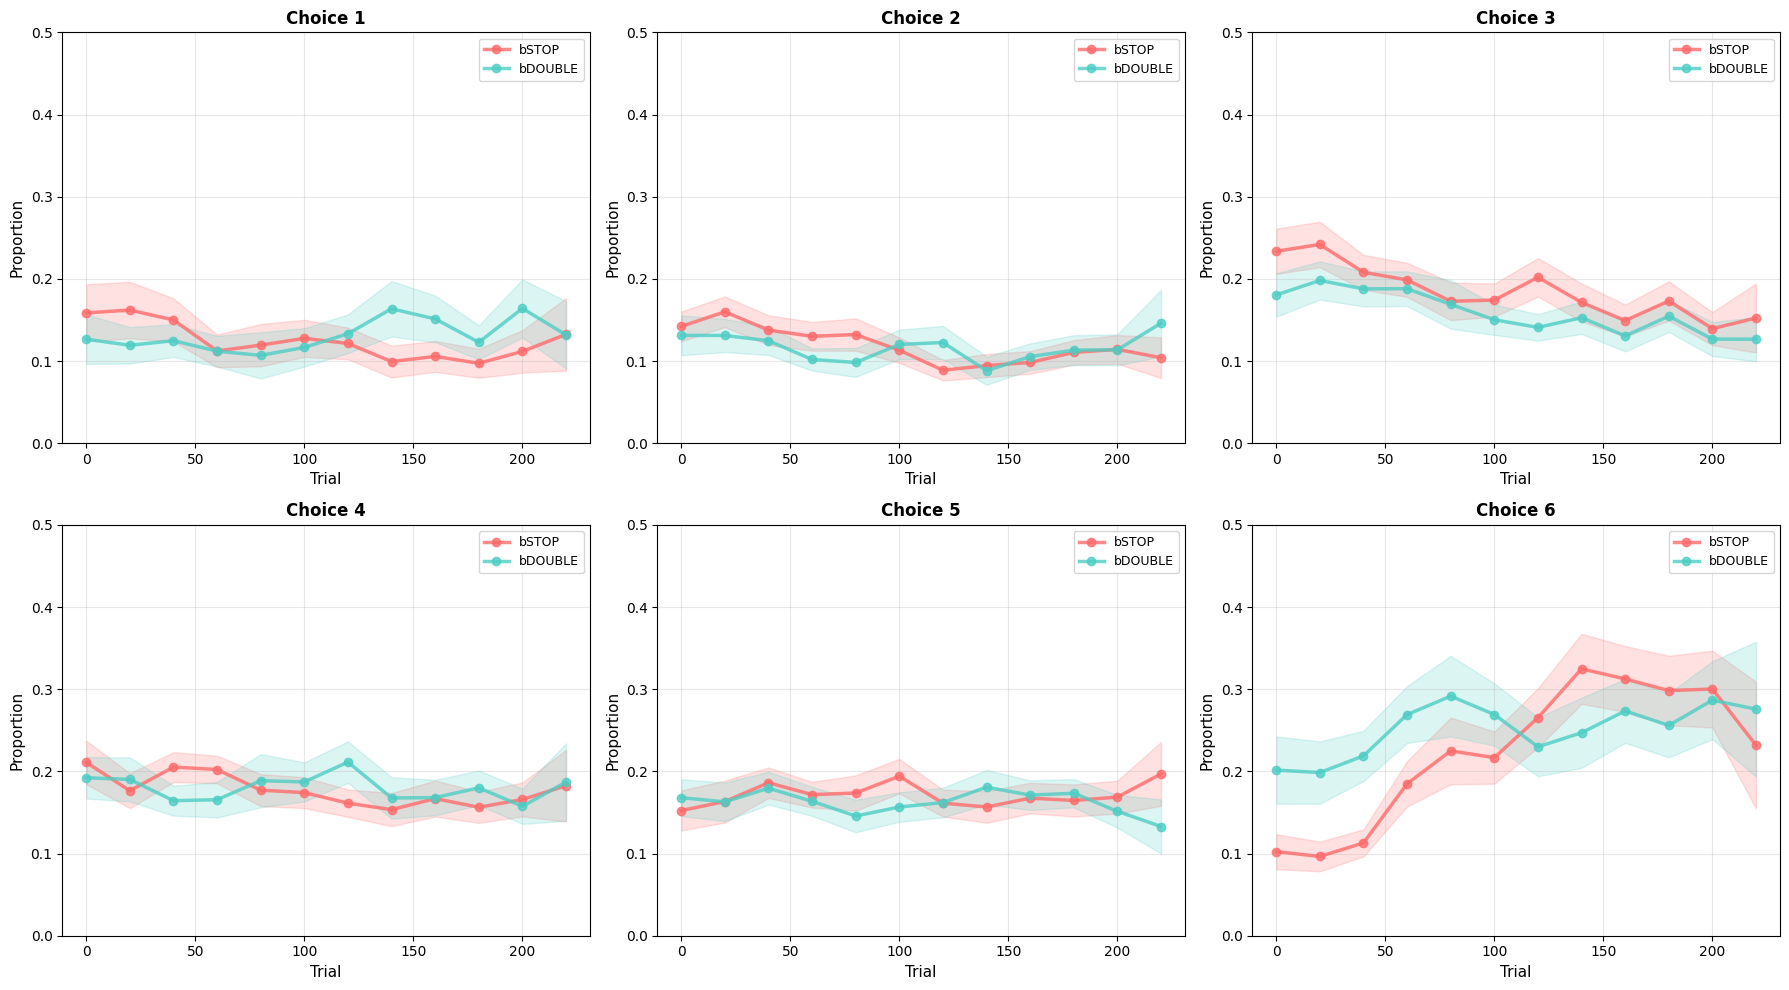

In [ ]:
all_choices = sorted(df['choice'].unique())
n_choices = len(all_choices)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, choice in enumerate(all_choices):
    ax = axes[idx]
    
    for group in df['group'].unique()[:2]:
        # Average across conditions for cleaner visualization
        group_data = choice_dist_summary[
            (choice_dist_summary['group'] == group) & 
            (choice_dist_summary['choice_option'] == choice)
        ]
        
        group_avg = group_data.groupby('trial_bin').agg({
            'mean_proportion': 'mean',
            'sem_proportion': 'mean'
        }).reset_index()
        
        color = '#FF6B6B' if group == df['group'].unique()[0] else '#4ECDC4'
        
        ax.plot(group_avg['trial_bin'], group_avg['mean_proportion'],
               'o-', color=color, linewidth=2.5, markersize=6, 
               alpha=0.8, label=group)
        ax.fill_between(group_avg['trial_bin'],
                       group_avg['mean_proportion'] - group_avg['sem_proportion'],
                       group_avg['mean_proportion'] + group_avg['sem_proportion'],
                       color=color, alpha=0.2)
    
    ax.set_title(f'Choice {int(choice)}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Trial', fontsize=11)
    ax.set_ylabel('Proportion', fontsize=11)
    ax.set_ylim(0, max(0.5, group_avg['mean_proportion'].max() * 1.2))  # Dynamic y-axis
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

# Hide extra subplot if there are fewer than 6 choices
for idx in range(n_choices, 6):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('choice_distribution_by_option.png', dpi=300, bbox_inches='tight')
plt.show()

Heat map of preference over time

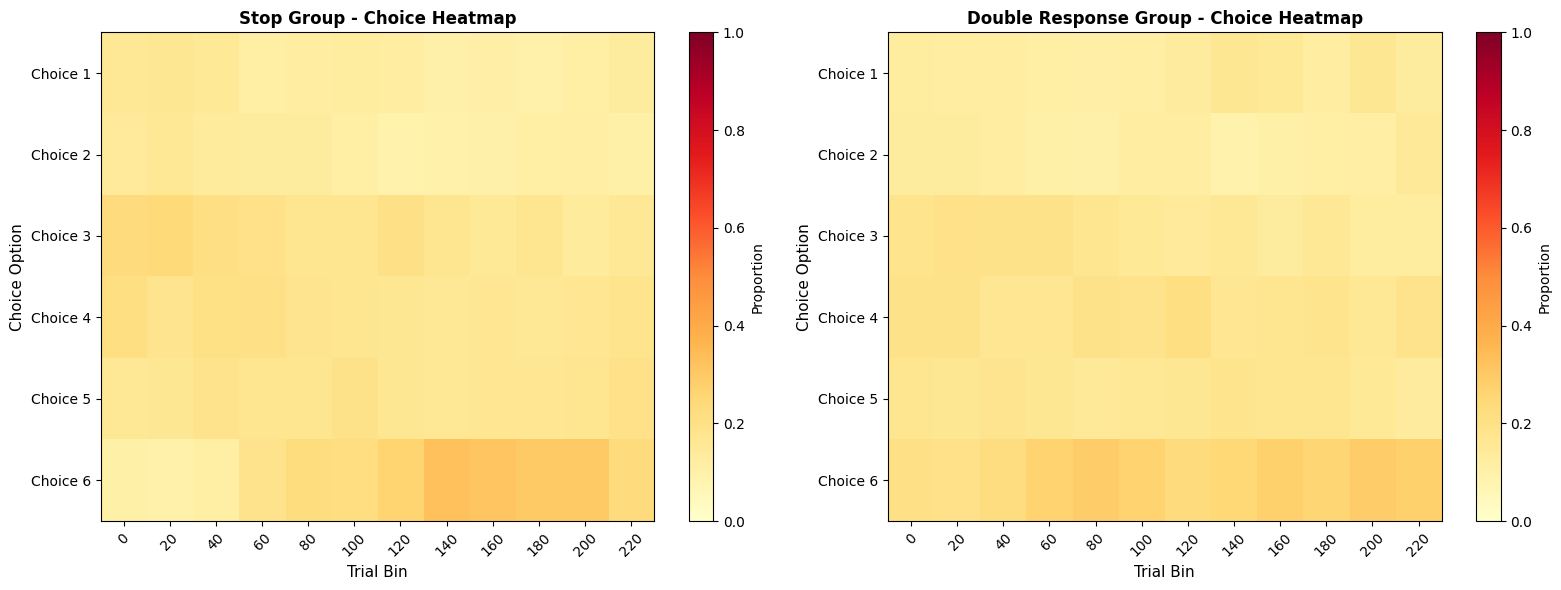

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for col_idx, group in enumerate(df['group'].unique()[:2]):
    ax = axes[col_idx]
    
    # Average across conditions
    group_data = choice_dist_summary[choice_dist_summary['group'] == group]
    
    heatmap_data = group_data.groupby(['trial_bin', 'choice_option']).agg({
        'mean_proportion': 'mean'
    }).reset_index()
    
    # Pivot for heatmap
    heatmap_pivot = heatmap_data.pivot(index='choice_option', columns='trial_bin', values='mean_proportion')
    heatmap_pivot = heatmap_pivot.fillna(0)
    
    # Create heatmap
    im = ax.imshow(heatmap_pivot, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    
    ax.set_yticks(range(len(heatmap_pivot.index)))
    ax.set_yticklabels([f'Choice {int(c)}' for c in heatmap_pivot.index])
    ax.set_xlabel('Trial Bin', fontsize=11)
    ax.set_ylabel('Choice Option', fontsize=11)
    ax.set_title(f"{'Stop' if group == "bSTOP" else 'Double Response'} Group" ' - Choice Heatmap', fontsize=12, fontweight='bold')
    
    # Set x-axis to show trial bins
    n_bins = len(heatmap_pivot.columns)
    ax.set_xticks(range(0, n_bins, max(1, n_bins // 10)))
    ax.set_xticklabels([int(heatmap_pivot.columns[i]) for i in range(0, n_bins, max(1, n_bins // 10))], rotation=45)
    
    plt.colorbar(im, ax=ax, label='Proportion')

plt.tight_layout()
plt.savefig('choice_distribution_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1667/1783887376.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([1, 2, 3, 4, 5, 6])
/tmp/ipykernel_1667/1783887376.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([1, 2, 3, 4, 5, 6])
/tmp/ipykernel_1667/1783887376.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([1, 2, 3, 4, 5, 6])
/tmp/ipykernel_1667/1783887376.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([1, 2, 3, 4, 5, 6])


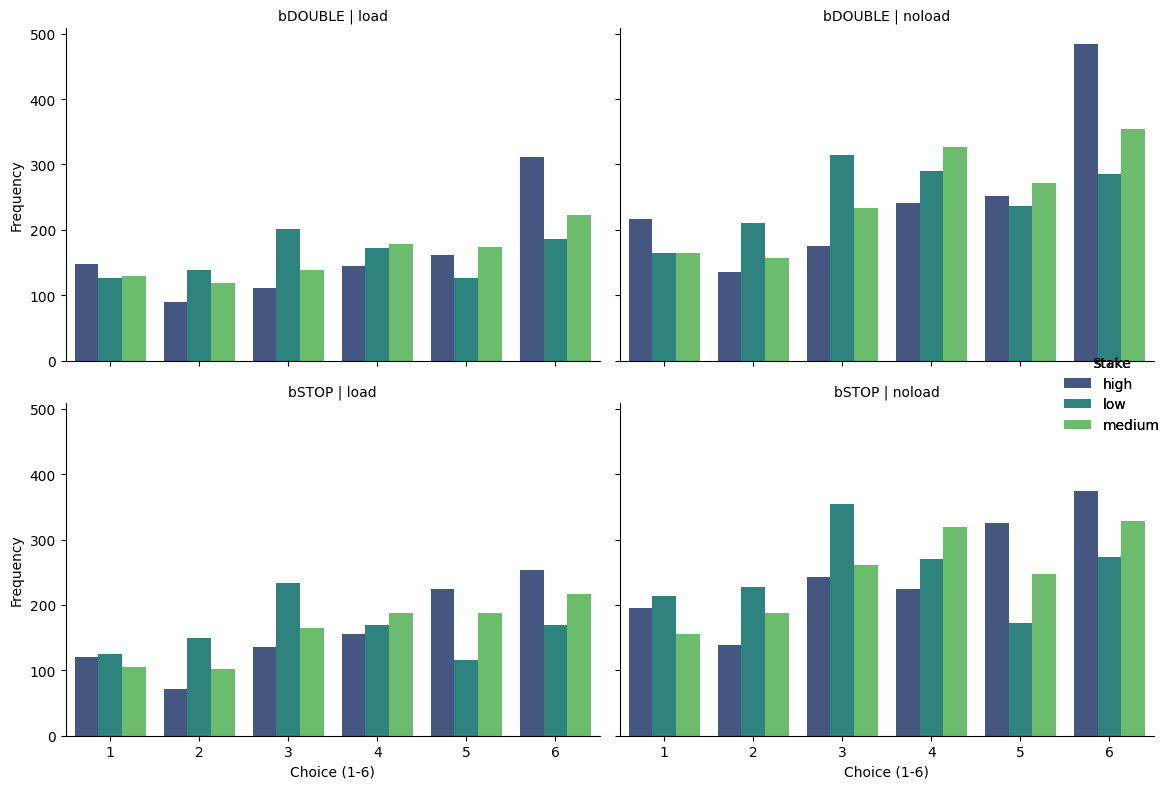

In [ ]:
# Calculate choice frequencies
choice_freq = df.groupby(['condition', 'group', 'stake', 'choice']).size().reset_index(name='count')

# Create the histogram
g = sns.catplot(
    data=choice_freq,
    x='choice',
    y='count',
    hue='stake',
    col='condition',
    row='group',
    kind='bar',
    height=4,
    aspect=1.2,
    palette='viridis'
)

# Customize
g.set_axis_labels("Choice (1-6)", "Frequency")
g.set_titles(col_template="{col_name}", row_template="{row_name}")
g.add_legend(title="Stake")

# Adjust x-axis to show 1-6 instead of 0-5
for ax in g.axes.flat:
    ax.set_xticklabels([1, 2, 3, 4, 5, 6])

plt.tight_layout()
plt.savefig('choice_histogram_exp1.png', dpi=300, bbox_inches='tight')
plt.show()